# 🏆 Mini Project — World Cup Team Performance Dashboard
### *Combining NumPy, Pandas & Matplotlib to go from raw match data → cleaned dataset → insights*

---

**Goal:** Take the raw `WorldCupMatches.csv` (one row per match) and build a **clean, impactful summary dataset** — one row per national team — with stats like total goals, win rate, average attendance, and goal difference. We'll save it as `team_performance_summary.csv` and visualise it.

**Steps:**
1. Load & clean the raw data (Pandas)
2. Engineer match-level features (Pandas + NumPy)
3. Aggregate into a team-level summary (Pandas groupby)
4. Compute extra stats with NumPy (e.g. consistency / std-dev of goals)
5. Save the cleaned, derived dataset as a CSV
6. Visualise the results (Matplotlib)

## Step 1 — Load & Clean the Raw Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.rcParams["figure.dpi"]  = 110
plt.rcParams["font.family"] = "DejaVu Sans"

# ── Load raw match-level data ──
raw = pd.read_csv("WorldCupMatches.csv")
print(f"Raw shape: {raw.shape}")

# ── Drop blank rows between tournaments ──
raw = raw.dropna(subset=["Year", "Home Team Name", "Home Team Goals", "Away Team Goals"])

# ── Fix data types ──
raw["Year"]            = raw["Year"].astype(int)
raw["Home Team Goals"] = raw["Home Team Goals"].astype(int)
raw["Away Team Goals"] = raw["Away Team Goals"].astype(int)
raw["Attendance"]      = pd.to_numeric(raw["Attendance"], errors="coerce")

# ── Strip whitespace from team/string columns ──
for col in ["Home Team Name", "Away Team Name", "City", "Stadium"]:
    raw[col] = raw[col].str.strip()

print(f"Clean shape: {raw.shape}  →  {raw['Year'].min()}–{raw['Year'].max()}")
raw.head(3)

Raw shape: (4572, 20)
Clean shape: (852, 20)  →  1930–2014


,Year,Datetime,Stage,Stadium,City,Home Team Name,Home Team Goals,Away Team Goals,Away Team Name,Win conditions,Attendance,Half-time Home Goals,Half-time Away Goals,Referee,Assistant 1,Assistant 2,RoundID,MatchID,Home Team Initials,Away Team Initials
0,1930,13 Jul 1930 - 15:00,Group 1,Pocitos,Montevideo,France,4,1,Mexico,,4444.0,3.0,0.0,LOMBARDI Domingo (URU),CRISTOPHE Henry (BEL),REGO Gilberto (BRA),201.0,1096.0,FRA,MEX
1,1930,13 Jul 1930 - 15:00,Group 4,Parque Central,Montevideo,USA,3,0,Belgium,,18346.0,2.0,0.0,MACIAS Jose (ARG),MATEUCCI Francisco (URU),WARNKEN Alberto (CHI),201.0,1090.0,USA,BEL
2,1930,14 Jul 1930 - 12:45,Group 2,Parque Central,Montevideo,Yugoslavia,2,1,Brazil,,24059.0,2.0,0.0,TEJADA Anibal (URU),VALLARINO Ricardo (URU),BALWAY Thomas (FRA),201.0,1093.0,YUG,BRA


## Step 2 — Engineer Match-Level Features

In [2]:
df = raw.copy()

df["Total Goals"] = df["Home Team Goals"] + df["Away Team Goals"]
df["Goal Diff"]   = df["Home Team Goals"] - df["Away Team Goals"]   # + means home won

df["Home Result"] = df["Goal Diff"].apply(
    lambda x: "Win" if x > 0 else ("Draw" if x == 0 else "Loss"))
df["Away Result"] = df["Goal Diff"].apply(
    lambda x: "Loss" if x > 0 else ("Draw" if x == 0 else "Win"))

print("New columns added:", ["Total Goals", "Goal Diff", "Home Result", "Away Result"])
df[["Year","Home Team Name","Away Team Name","Home Team Goals","Away Team Goals",
    "Total Goals","Home Result"]].head(5)

New columns added: ['Total Goals', 'Goal Diff', 'Home Result', 'Away Result']


,Year,Home Team Name,Away Team Name,Home Team Goals,Away Team Goals,Total Goals,Home Result
0,1930,France,Mexico,4,1,5,Win
1,1930,USA,Belgium,3,0,3,Win
2,1930,Yugoslavia,Brazil,2,1,3,Win
3,1930,Romania,Peru,3,1,4,Win
4,1930,Argentina,France,1,0,1,Win


## Step 3 — Reshape to One Row per Team per Match
Each match involves two teams. To build a **team-level** summary, we first turn each match into two "team-perspective" rows (one for the home side, one for the away side) — a classic Pandas reshaping trick.

In [3]:
home_view = df.rename(columns={
    "Home Team Name": "Team", "Away Team Name": "Opponent",
    "Home Team Goals": "Goals For", "Away Team Goals": "Goals Against",
    "Home Result": "Result"
})[["Year","Team","Opponent","Goals For","Goals Against","Result","Attendance","Stage"]]

away_view = df.rename(columns={
    "Away Team Name": "Team", "Home Team Name": "Opponent",
    "Away Team Goals": "Goals For", "Home Team Goals": "Goals Against",
    "Away Result": "Result"
})[["Year","Team","Opponent","Goals For","Goals Against","Result","Attendance","Stage"]]

team_matches = pd.concat([home_view, away_view], ignore_index=True)
team_matches["Goal Diff"] = team_matches["Goals For"] - team_matches["Goals Against"]

print(f"Team-perspective rows: {len(team_matches)}  (= 2 × {len(df)} matches)")
team_matches.head(5)

Team-perspective rows: 1704  (= 2 × 852 matches)


,Year,Team,Opponent,Goals For,Goals Against,Result,Attendance,Stage,Goal Diff
0,1930,France,Mexico,4,1,Win,4444.0,Group 1,3
1,1930,USA,Belgium,3,0,Win,18346.0,Group 4,3
2,1930,Yugoslavia,Brazil,2,1,Win,24059.0,Group 2,1
3,1930,Romania,Peru,3,1,Win,2549.0,Group 3,2
4,1930,Argentina,France,1,0,Win,23409.0,Group 1,1


## Step 4 — Aggregate Into a Team Performance Summary (groupby)

In [4]:
summary = team_matches.groupby("Team").agg(
    Matches_Played   = ("Result",        "count"),
    Wins             = ("Result",        lambda s: (s == "Win").sum()),
    Draws            = ("Result",        lambda s: (s == "Draw").sum()),
    Losses           = ("Result",        lambda s: (s == "Loss").sum()),
    Goals_For        = ("Goals For",     "sum"),
    Goals_Against     = ("Goals Against", "sum"),
    Avg_Attendance   = ("Attendance",    "mean"),
    First_WC_Year    = ("Year",          "min"),
    Last_WC_Year     = ("Year",          "max"),
).reset_index()

summary["Win Rate %"]   = (summary["Wins"] / summary["Matches_Played"] * 100).round(1)
summary["Goal Diff"]    = summary["Goals_For"] - summary["Goals_Against"]
summary["Avg_Attendance"] = summary["Avg_Attendance"].round(0)

# Only keep teams with a meaningful number of matches (reduces noise from one-off qualifiers)
summary = summary[summary["Matches_Played"] >= 5].copy()
summary = summary.sort_values("Goals_For", ascending=False).reset_index(drop=True)

print(f"Teams in summary (≥5 matches played): {len(summary)}")
summary.head(10)

Teams in summary (≥5 matches played): 63


,Team,Matches_Played,Wins,Draws,Losses,Goals_For,Goals_Against,Avg_Attendance,First_WC_Year,Last_WC_Year,Win Rate %,Goal Diff
0,Brazil,108,71,18,19,225,114,54862.0,1930,2014,65.7,111
1,Argentina,81,44,15,22,133,85,53186.0,1930,2014,54.3,48
2,Germany FR,62,36,14,12,131,77,52803.0,1954,1990,58.1,54
3,Italy,83,45,21,17,128,77,50711.0,1934,2014,54.2,51
4,France,61,29,12,20,108,72,45692.0,1930,2014,47.5,36
5,Germany,48,34,6,8,104,46,50172.0,1934,2014,70.8,58
6,Spain,59,29,12,18,92,66,44728.0,1934,2014,49.2,26
7,Netherlands,54,29,14,11,91,49,53111.0,1934,2014,53.7,42
8,Hungary,32,15,3,14,87,57,26568.0,1934,1986,46.9,30
9,Uruguay,52,20,12,20,80,73,44508.0,1930,2014,38.5,7


## Step 5 — Add a NumPy-Powered Consistency Score
Pandas handles the aggregation, but for a custom stat — *how consistent is a team's scoring (standard deviation of goals per match)* — we drop into raw NumPy arrays for the calculation.

In [5]:
consistency = {}
for team, grp in team_matches.groupby("Team"):
    goals_arr = np.array(grp["Goals For"])     # NumPy array of goals scored, match by match
    if len(goals_arr) >= 5:
        consistency[team] = np.std(goals_arr)   # lower std = more consistent scoring

summary["Goal Std Dev"] = summary["Team"].map(consistency).round(2)

print("Most consistent attackers (low std dev, min 5 matches):")
summary.sort_values("Goal Std Dev").head(5)[["Team","Matches_Played","Goals_For","Goal Std Dev"]]

Most consistent attackers (low std dev, min 5 matches):


,Team,Matches_Played,Goals_For,Goal Std Dev
61,El Salvador,6,1,0.37
62,Bolivia,6,1,0.37
60,IR Iran,6,2,0.47
59,Honduras,9,3,0.47
41,Northern Ireland,13,13,0.68


## Step 6 — Save the Cleaned, Derived Dataset

In [6]:
output_cols = ["Team","Matches_Played","Wins","Draws","Losses","Goals_For","Goals_Against",
               "Goal Diff","Win Rate %","Avg_Attendance","Goal Std Dev",
               "First_WC_Year","Last_WC_Year"]

clean_dataset = summary[output_cols].sort_values("Win Rate %", ascending=False).reset_index(drop=True)
clean_dataset.to_csv("team_performance_summary.csv", index=False)

print(f"✔ Saved 'team_performance_summary.csv' — {clean_dataset.shape[0]} teams, {clean_dataset.shape[1]} columns")
clean_dataset.head(10)

✔ Saved 'team_performance_summary.csv' — 63 teams, 13 columns


,Team,Matches_Played,Wins,Draws,Losses,Goals_For,Goals_Against,Goal Diff,Win Rate %,Avg_Attendance,Goal Std Dev,First_WC_Year,Last_WC_Year
0,Germany,48,34,6,8,104,46,58,70.8,50172.0,1.81,1934,2014
1,Brazil,108,71,18,19,225,114,111,65.7,54862.0,1.55,1930,2014
2,Germany FR,62,36,14,12,131,77,54,58.1,52803.0,1.64,1954,1990
3,Argentina,81,44,15,22,133,85,48,54.3,53186.0,1.51,1930,2014
4,Italy,83,45,21,17,128,77,51,54.2,50711.0,1.21,1934,2014
5,Netherlands,54,29,14,11,91,49,42,53.7,53111.0,1.33,1934,2014
6,Portugal,26,13,4,9,43,29,14,50.0,48723.0,1.71,1966,2014
7,Denmark,16,8,2,6,27,24,3,50.0,40878.0,1.45,1986,2010
8,Turkey,10,5,1,4,20,17,3,50.0,38319.0,1.90,1954,2002
9,Spain,59,29,12,18,92,66,26,49.2,44728.0,1.28,1934,2014


## Step 7 — Visualise the Insights
### 7.1 — Top 10 Teams by Total Goals Scored

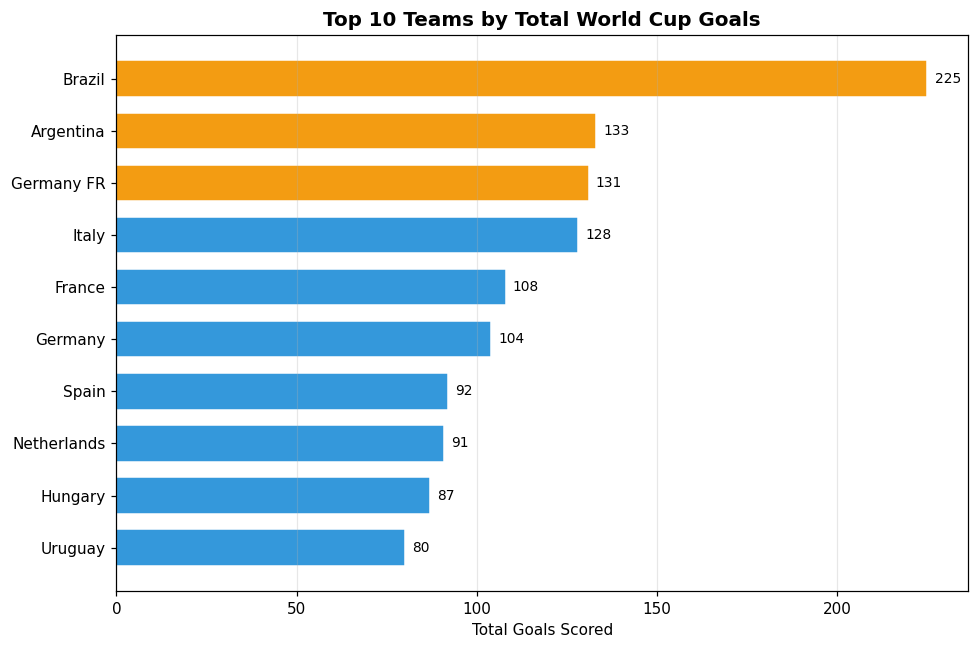

In [7]:
top10 = clean_dataset.sort_values("Goals_For", ascending=False).head(10)

fig, ax = plt.subplots(figsize=(9, 6))
colors = ["#f39c12" if i < 3 else "#3498db" for i in range(len(top10))]
bars = ax.barh(top10["Team"], top10["Goals_For"], color=colors, edgecolor="white", height=0.7)

for bar, val in zip(bars, top10["Goals_For"]):
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
            f"{int(val)}", va="center", fontsize=9)

ax.invert_yaxis()
ax.set_xlabel("Total Goals Scored")
ax.set_title("Top 10 Teams by Total World Cup Goals", fontsize=13, fontweight="bold")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

### 7.2 — Win Rate vs Matches Played (Scatter)

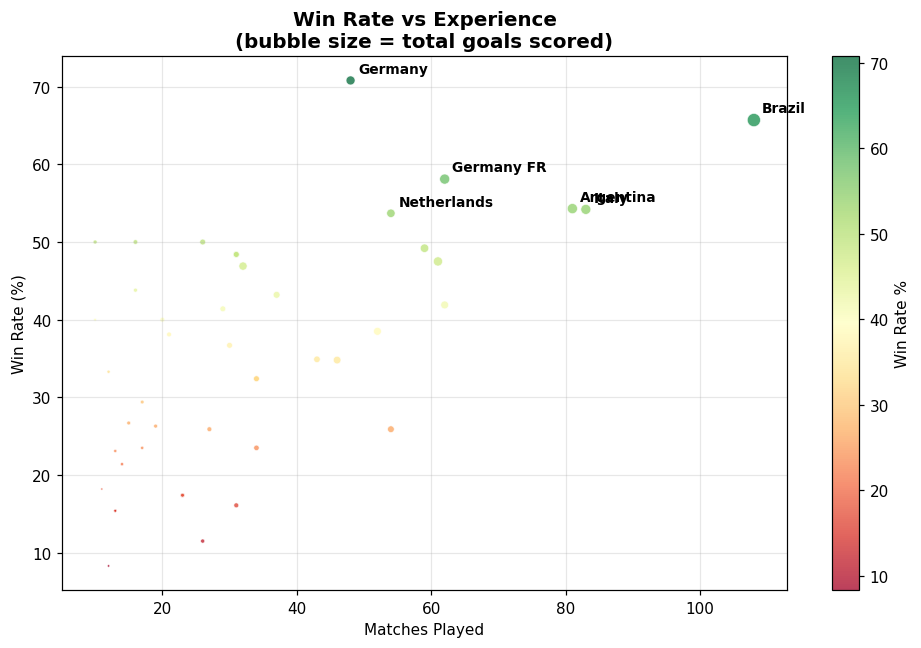

In [8]:
plot_df = clean_dataset[clean_dataset["Matches_Played"] >= 10]

fig, ax = plt.subplots(figsize=(9, 6))
sizes = plot_df["Goals_For"] / 3   # bubble size ~ goals scored

scatter = ax.scatter(plot_df["Matches_Played"], plot_df["Win Rate %"],
                      s=sizes, c=plot_df["Win Rate %"], cmap="RdYlGn",
                      alpha=0.75, edgecolors="white", linewidth=0.5)

# Label the standout teams
for _, row in plot_df.nlargest(6, "Win Rate %").iterrows():
    ax.annotate(row["Team"], (row["Matches_Played"], row["Win Rate %"]),
                xytext=(5, 5), textcoords="offset points", fontsize=9, fontweight="bold")

ax.set_xlabel("Matches Played")
ax.set_ylabel("Win Rate (%)")
ax.set_title("Win Rate vs Experience\n(bubble size = total goals scored)",
             fontsize=13, fontweight="bold")
ax.grid(True, alpha=0.3)
plt.colorbar(scatter, label="Win Rate %")
plt.tight_layout()
plt.show()

### 7.3 — Goal Difference: Best & Worst Records

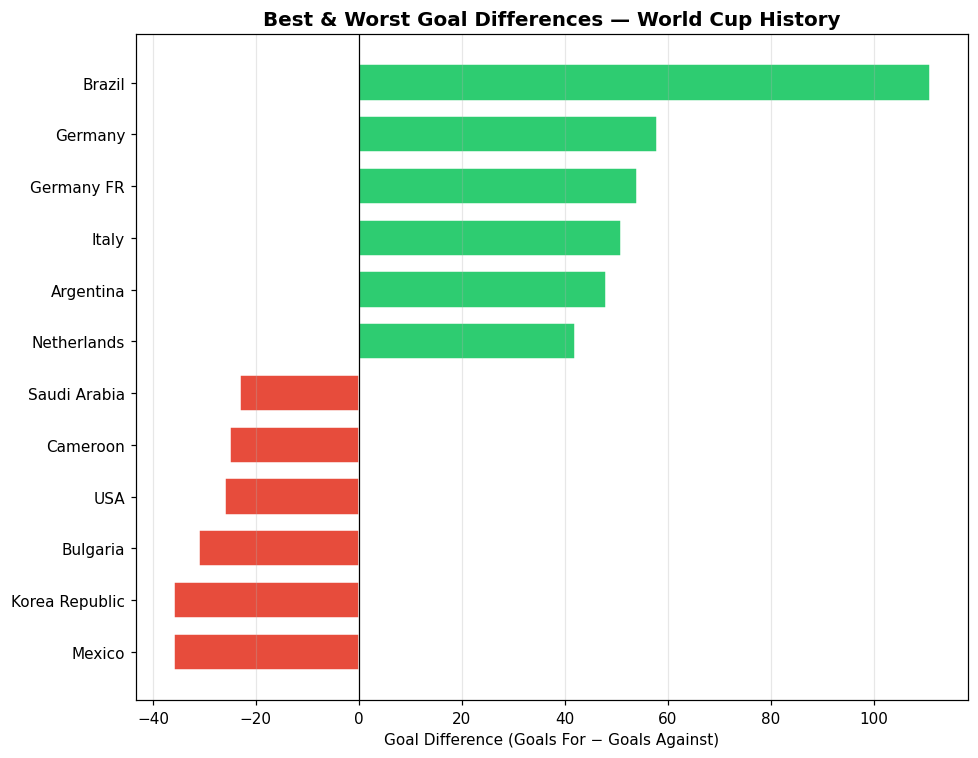

In [9]:
best_worst = pd.concat([
    clean_dataset.nlargest(6, "Goal Diff"),
    clean_dataset.nsmallest(6, "Goal Diff")
]).sort_values("Goal Diff")

fig, ax = plt.subplots(figsize=(9, 7))
colors = ["#e74c3c" if v < 0 else "#2ecc71" for v in best_worst["Goal Diff"]]
ax.barh(best_worst["Team"], best_worst["Goal Diff"], color=colors, edgecolor="white", height=0.7)
ax.axvline(0, color="black", linewidth=0.8)

ax.set_xlabel("Goal Difference (Goals For − Goals Against)")
ax.set_title("Best & Worst Goal Differences — World Cup History",
             fontsize=13, fontweight="bold")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

### 7.4 — Summary Dashboard

/tmp/ipykernel_679/2941083795.py:38: UserWarning: Glyph 9917 (\N{SOCCER BALL}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0, 1, 0.96])


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9917 (\N{SOCCER BALL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


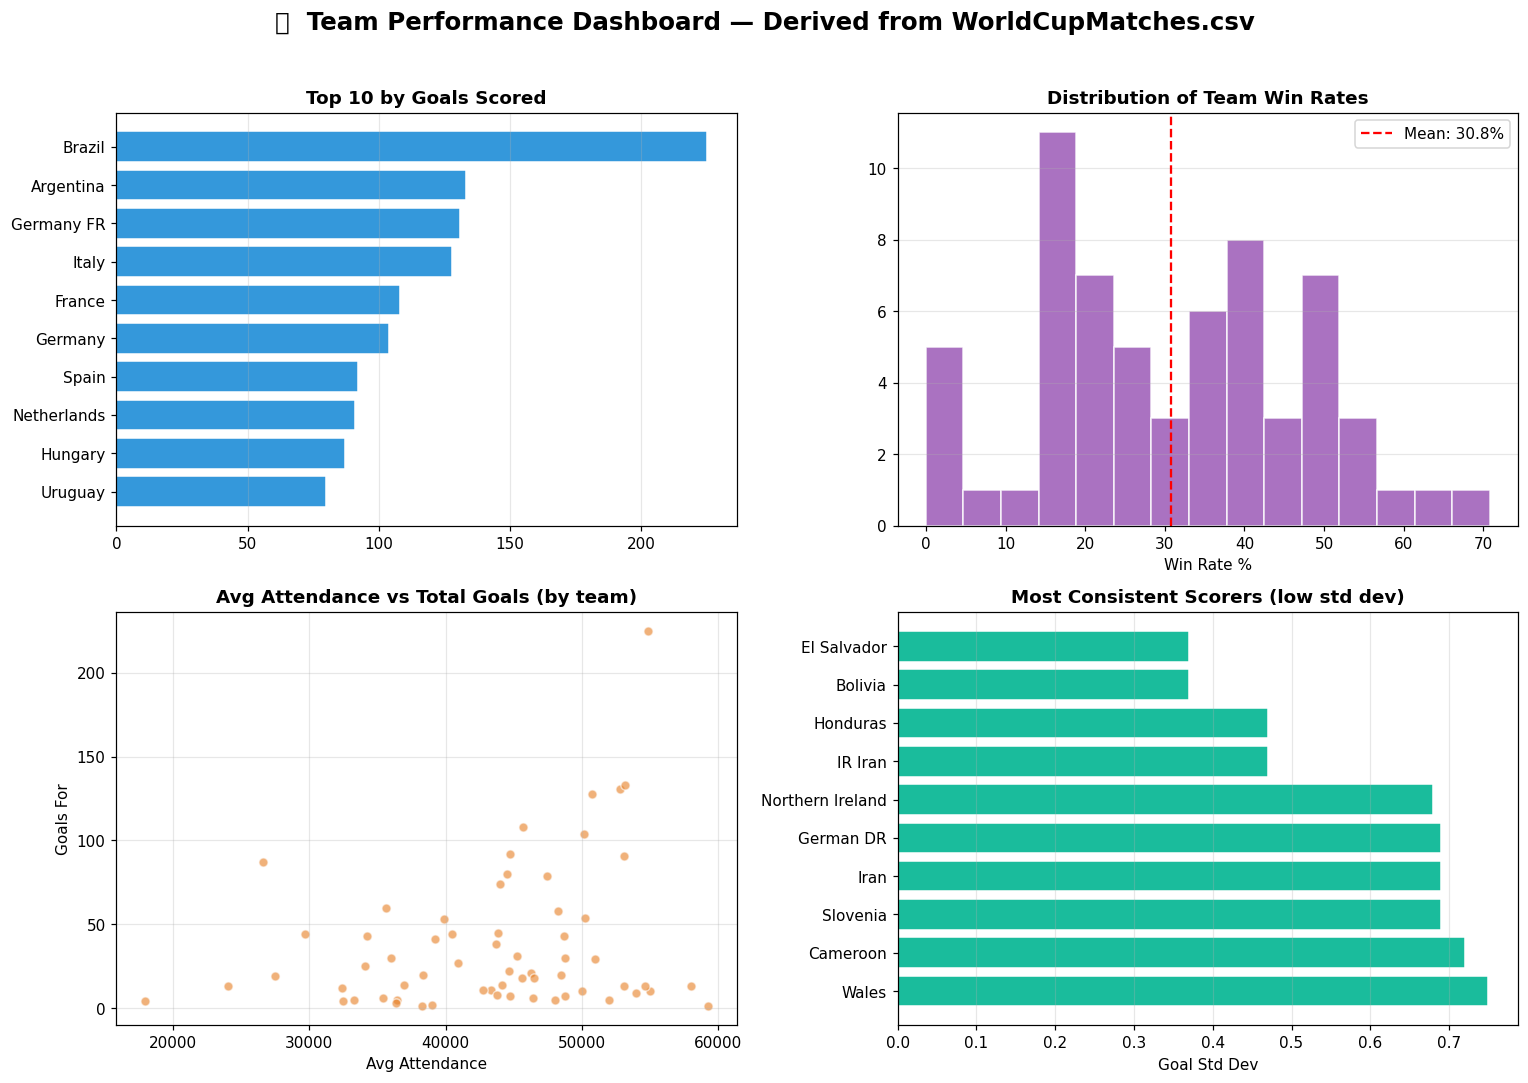

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("⚽  Team Performance Dashboard — Derived from WorldCupMatches.csv",
             fontsize=16, fontweight="bold", y=0.98)

# Panel 1: Top scorers
t10 = clean_dataset.sort_values("Goals_For", ascending=False).head(10)
axes[0,0].barh(t10["Team"], t10["Goals_For"], color="#3498db", edgecolor="white")
axes[0,0].invert_yaxis()
axes[0,0].set_title("Top 10 by Goals Scored", fontweight="bold")
axes[0,0].grid(axis="x", alpha=0.3)

# Panel 2: Win rate distribution
axes[0,1].hist(clean_dataset["Win Rate %"], bins=15, color="#9b59b6",
               edgecolor="white", alpha=0.85)
axes[0,1].axvline(clean_dataset["Win Rate %"].mean(), color="red", linestyle="--",
                   label=f"Mean: {clean_dataset['Win Rate %'].mean():.1f}%")
axes[0,1].set_title("Distribution of Team Win Rates", fontweight="bold")
axes[0,1].set_xlabel("Win Rate %")
axes[0,1].legend()
axes[0,1].grid(axis="y", alpha=0.3)

# Panel 3: Attendance vs goals (correlation)
axes[1,0].scatter(clean_dataset["Avg_Attendance"], clean_dataset["Goals_For"],
                   alpha=0.6, color="#e67e22", edgecolors="white")
axes[1,0].set_title("Avg Attendance vs Total Goals (by team)", fontweight="bold")
axes[1,0].set_xlabel("Avg Attendance")
axes[1,0].set_ylabel("Goals For")
axes[1,0].grid(True, alpha=0.3)

# Panel 4: Most consistent scorers
consistent = clean_dataset.dropna(subset=["Goal Std Dev"]).nsmallest(10, "Goal Std Dev")
axes[1,1].barh(consistent["Team"], consistent["Goal Std Dev"], color="#1abc9c", edgecolor="white")
axes[1,1].invert_yaxis()
axes[1,1].set_title("Most Consistent Scorers (low std dev)", fontweight="bold")
axes[1,1].set_xlabel("Goal Std Dev")
axes[1,1].grid(axis="x", alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## Summary

We went from a **raw, match-level CSV** (4572 rows, lots of missing/blank rows) to a **clean, team-level dataset** (`team_performance_summary.csv`) with meaningful derived stats — wins, goal difference, win rate, attendance, and a NumPy-computed consistency score — then used Matplotlib to surface insights a single table couldn't show on its own.

**Concepts used together:**
- **NumPy** → `np.std()` for the goal-consistency calculation on raw arrays
- **Pandas** → cleaning, type conversion, reshaping (`concat`), `groupby().agg()`, filtering, `to_csv()`
- **Matplotlib** → bar, scatter, histogram, and a multi-panel dashboard

🎯 **Try it yourself:** change the `Matches_Played >= 5` filter, add a new derived column (e.g. goals per match), or visualise a different slice of `team_performance_summary.csv`.